In [1]:
! git clone https://github.com/fssdfhsdfsdk/CUDA-by-Example-source-code-for-the-book-s-examples-.git

Cloning into 'CUDA-by-Example-source-code-for-the-book-s-examples-'...
remote: Enumerating objects: 136, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 136 (delta 46), reused 41 (delta 41), pack-reused 82 (from 1)
Receiving objects: 100% (136/136), 1.10 MiB | 4.20 MiB/s, done.
Resolving deltas: 100% (68/68), done.


In [2]:
%cd /content/CUDA-by-Example-source-code-for-the-book-s-examples- 

/content/CUDA-by-Example-source-code-for-the-book-s-examples-


## add_loop_cpu.cu

In [3]:
%%writefile add_loop_cpu.cu

#include "common/book.h"
#define N 10

void add(int *a, int *b, int *c) {
    int tid = 0;
    while(tid < N) {
        c[tid] = a[tid] + b[tid];
        tid ++;  // 只有一个cpu，每次只加1
    }
}


int main(void) {
    int a[N], b[N], c[N];

    for(int i=0; i < N; i++) {
        a[i] = -i;
        b[i] = i * i;
    }



    add(a, b, c);

    for(int i=0; i < N; i++) {
        printf("%d ", c[i]);
    } 
    printf("\n");

    return 0;
}



Writing add_loop_cpu.cu


In [4]:
! nvcc add_loop_cpu.cu -arch=sm_75 -o hello && date; ./hello; date

Sun Mar  8 12:34:38 PM UTC 2026
0 0 2 6 12 20 30 42 56 72 
Sun Mar  8 12:34:38 PM UTC 2026


这個 **Segmentation fault (段错误)** 是因为你把太大的数组放进了 **栈 (Stack)** 里。


核心原因
在 C 语言中，函数内部定义的 `int a[N]` 属于局部变量，存储在栈空间。

-   你的 `N` 是 `1,000,000`。
- 三个 `int` 数组总共占用：12MB
-   大多数 Linux 系统的默认栈限制（ulimit）只有 **8MB**。
-   一旦程序运行，内存需求超过栈容量，直接崩掉。

ulimit -s unlimited;

## add_loop_cpu_pthread.cu

In [54]:
%%writefile add_loop_cpu_pthread.cu

#include "common/book.h"
#include <iostream>
#include <pthread.h>
#include <string>
#define N 10

// 1. 定义参数结构体
struct ThreadArgs {
    int * a;
    int * b;
    int * c;
    int tid;
};

void* add(void *arg) {
    ThreadArgs* data = static_cast<ThreadArgs*>(arg);

    int tid = data->tid;
    while(tid < N) {
        data->c[tid] = data->b[tid] + data->a[tid];
        tid ++;
    }
    delete data;
    return nullptr;
}




int main(void) {
    int a[N], b[N], c[N];

    const int NUM_THREADS = 2;
    pthread_t threads[NUM_THREADS]; // 线程句柄数组

    for(int i=0; i < N; i++) {
        a[i] = -i;
        b[i] = i * i;
    }



    for (long i = 0; i < NUM_THREADS; i++) {
        ThreadArgs* args = new ThreadArgs();
        args->a = a;
        args->b = b;
        args->c = c;
        args->tid = i; 
        // 3. 创建线程：句柄, 属性(通常NULL), 函数名, 参数
        int rc = pthread_create(&threads[i], NULL, add, (void*)args);
        
        if (rc) {
            std::cerr << "错误：无法创建线程," << rc << std::endl;
            exit(-1);
        }
    }

    for (int i = 0; i < NUM_THREADS; i++) {
        void* status;
        pthread_join(threads[i], &status);
        std::cout << "线程 " << i << " 已结束，返回码: " << (long)status << std::endl;
    }


    for(int i=0; i < N; i++) {
        printf("%d ", c[i]);
    }


    return 0;
}



Overwriting add_loop_cpu_pthread.cu


In [55]:
! nvcc add_loop_cpu_pthread.cu -arch=sm_75 -o hello && ./hello

线程 0 已结束，返回码: 0
线程 1 已结束，返回码: 0
0 0 2 6 12 20 30 42 56 72 

## add_loop_gpu.cu



In [56]:
%%writefile add_loop_gpu.cu
#include "common/book.h"

#define N 100000


__global__ void add(int *a, int *b, int *c) {
    int tid = blockIdx.x;
    while(tid < N) {
        c[tid] = a[tid] + b[tid];
        tid += N;
    }
}


int main(void) {
    int a[N], b[N], c[N];
    int * dev_a, * dev_b, * dev_c;

    for(int i=0; i < N; i++) {
        a[i] = -i;
        b[i] = i * i;
    }

    HANDLE_ERROR( cudaMalloc((void **)&dev_a, N * sizeof(int)));
    HANDLE_ERROR( cudaMalloc((void **)&dev_b, N * sizeof(int)));
    HANDLE_ERROR( cudaMalloc((void **)&dev_c, N * sizeof(int)));

    HANDLE_ERROR( cudaMemcpy(dev_a, a, N * sizeof(int), cudaMemcpyHostToDevice));
    HANDLE_ERROR( cudaMemcpy(dev_b, b, N * sizeof(int), cudaMemcpyHostToDevice));

    add<<<N,1>>>(dev_a, dev_b, dev_c);

    HANDLE_ERROR( cudaMemcpy(c, dev_c, N * sizeof(int), cudaMemcpyDeviceToHost));

/*
    for(int i=0; i < N; i++) {
        printf("%d ", c[i]);
    }
*/

    cudaFree(dev_a);
    cudaFree(dev_b);
    cudaFree(dev_c);

    return 0;
}

Overwriting add_loop_gpu.cu


测试运行：
 - 100000（10w个block），正常运行

In [58]:
! nvcc add_loop_gpu.cu -arch=sm_75 -o hello && date; ./hello; date;date

Fri Mar  6 04:05:43 AM UTC 2026
Fri Mar  6 04:05:44 AM UTC 2026
Fri Mar  6 04:05:44 AM UTC 2026


## julia_cpu.cu

In [59]:
%%writefile julia_cpu.cu

#include "common/book.h"
#include "common/cpu_bitmap.h"

#define DIM 1000

struct cuComplex {
    float   r;
    float   i;
    cuComplex( float a, float b ) : r(a), i(b)  {}
    float magnitude2( void ) { return r * r + i * i; }
    cuComplex operator*(const cuComplex& a) {
        return cuComplex(r*a.r - i*a.i, i*a.r + r*a.i);
    }
    cuComplex operator+(const cuComplex& a) {
        return cuComplex(r+a.r, i+a.i);
    }
};

int julia( int x, int y ) { 
    const float scale = 1.5;
    float jx = scale * (float)(DIM/2 - x)/(DIM/2);
    float jy = scale * (float)(DIM/2 - y)/(DIM/2);

    cuComplex c(-0.805, 0.1685);
    cuComplex a(jx, jy);

    int i = 0;
    for (i=0; i<200; i++) {
        a = a * a + c;
        if (a.magnitude2() > 1000)
            return 0;
    }

    return 1;
}

void kernel( unsigned char *ptr ){
    for (int y=0; y<DIM; y++) {
        for (int x=0; x<DIM; x++) {
            int offset = x + y * DIM;

            int juliaValue = julia( x, y );
            ptr[offset*4 + 0] = 255 * juliaValue;
            ptr[offset*4 + 1] = 0;
            ptr[offset*4 + 2] = 0;
            ptr[offset*4 + 3] = 255;
        }
    }
 }

int main( void ) {
    CPUBitmap bitmap( DIM, DIM );
    unsigned char *ptr = bitmap.get_ptr();

    kernel( ptr );

    bitmap.save_ppm("julia.ppm");
    return 0;
}



Writing julia_cpu.cu


### 某个云环境：

 - （无需 OpenGL 库）

```
In file included from /usr/local/cuda-12.2/bin/../targets/x86_64-linux/include/cuda_runtime.h:82,
                 from <command-line>:
/usr/local/cuda-12.2/bin/../targets/x86_64-linux/include/crt/host_config.h:143:2: error: #error -- unsupported GNU version! gcc versions later than 12 are not supported! The nvcc flag '-allow-unsupported-compiler' can be used to override this version check; however, using an unsupported host compiler may cause compilation failure or incorrect run time execution. Use at your own risk.
  143 | #error -- unsupported GNU version! gcc versions later than 12 are not supported! The nvcc flag '-allow-unsupported-compiler' can be used to override this version check; however, using an unsupported host compiler may cause compilation failure or incorrect run time execution. Use at your own risk.
      |  ^~~~~
```

- 编译器版本不相容问题，您的系統 gcc 版本太新（可能是 13 或更高），而 CUDA 12.2 官方仅仅支持到gcc 12

In [ ]:
! sudo apt update && sudo apt install gcc-12 g++-12
! nvcc julia_cpu.cu -arch=sm_75 -o hello -ccbin /usr/bin/g++-12 && ./hello
! convert julia.ppm julia.png
! cp julia.png /workspace 

## julia_gpu.cu

In [ ]:
%%writefile julia_gpu.cu

#include "common/book.h"
#include "common/cpu_bitmap.h"


#define DIM 1000

struct cuCpmplex {
    float r; //bug: type int 图像不符合预期
    float i;
    __device__ cuCpmplex(float a, float b): r(a), i(b) {};

    __device__ float lenth() {
        return r * r + i * i;
    }

    __device__ cuCpmplex operator*(const cuCpmplex &a){
        return cuCpmplex(r * a.r - i * a.i, r * a.i + i * a.r);
    }

    __device__ cuCpmplex operator+(const cuCpmplex &a){
        return cuCpmplex(r + a.r, i + a.i);
    }

};

// struct DataBlock {
//     unsigned char * dev_bitmap;
// }


__device__ int julia(int a, int b) {

    const float scale = 1.5;
    float jx = scale * (float)(DIM/2 - a)/(DIM/2);
    float jy = scale * (float)(DIM/2 - b)/(DIM/2);

    cuCpmplex z(jx, jy);
    cuCpmplex c(-0.8, 0.156);

    for(int i=0; i < 200; i++) {
        z = z*z + c;
        if(z.lenth() > 1000) {
            return 0;
        }
    }
    return 1;
}

__global__ void kernel(unsigned char * data_ptr) {
    int x = blockIdx.x;
    int y = blockIdx.y;
    int offset = x +  y * gridDim.x;

    int juliaval = julia(x, y);
 
    data_ptr[4 * offset + 0] = 255 * juliaval;
    data_ptr[4 * offset + 1] = 0;
    data_ptr[4 * offset + 2] = 0;
    data_ptr[4 * offset + 3] = 255;
}



int main(void) {
    // DataBlock data;
    CPUBitmap bitmap(DIM, DIM);
    unsigned char *dev_bitmap;

    printf("Allocating GPU memory...\n");
    HANDLE_ERROR(cudaMalloc((void **)&dev_bitmap, bitmap.image_size()));

    // data.dev_bitmap = dev_bitmap;

    dim3 grid(DIM, DIM);
    printf("Running kernel...\n");
    kernel<<<grid, 1>>>(dev_bitmap);

    printf("Copying back to Host...\n");
    HANDLE_ERROR( cudaMemcpy(bitmap.get_ptr(), dev_bitmap, bitmap.image_size(), cudaMemcpyDeviceToHost));

    printf("Saving ...\n");
    bitmap.save_ppm("julia.ppm");
    cudaFree(dev_bitmap); // 良好的习惯：手动释放显存
    return 0;
}


Overwriting julia_gpu.cu


In [36]:
! nvcc julia_gpu.cu -arch=sm_75 -o hello && date; ./hello; date

common/cpu_bitmap.h(69): warning #2464-D: conversion from a string literal to "char *" is deprecated
          char* dummy = "";
                        ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

common/cpu_bitmap.h(69): warning #2464-D: conversion from a string literal to "char *" is deprecated
          char* dummy = "";
                        ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Sun Mar  8 12:58:18 PM UTC 2026
Allocating GPU memory...
Running kernel...
Copying back to Host...
Saving ...
✓ Image saved to julia.ppm
Sun Mar  8 12:58:19 PM UTC 2026


In [37]:
! python3 -c "from PIL import Image; Image.open('julia.ppm').save('julia.png')"

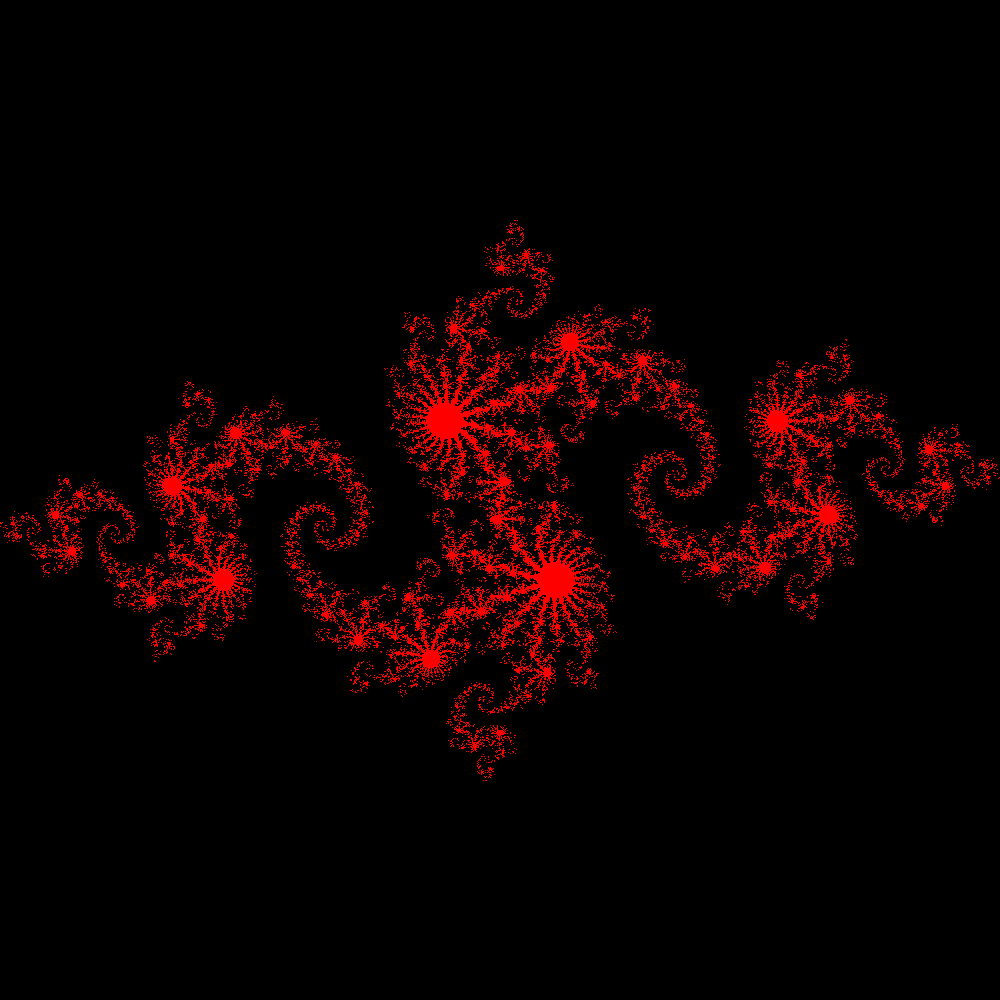

In [38]:
from IPython.display import Image
Image(filename='julia.png') 

## python-julia

In [8]:
import numpy as np
import matplotlib.pyplot as plt

zoom = 10

x = np.linspace(-zoom, zoom, 5)
y = np.linspace(-zoom-1, zoom+1, 5)
X, Y = np.meshgrid(x, y)
print(x)
print(y)
print(X)
print(Y)

[-10.  -5.   0.   5.  10.]
[-11.   -5.5   0.    5.5  11. ]
[[-10.  -5.   0.   5.  10.]
 [-10.  -5.   0.   5.  10.]
 [-10.  -5.   0.   5.  10.]
 [-10.  -5.   0.   5.  10.]
 [-10.  -5.   0.   5.  10.]]
[[-11.  -11.  -11.  -11.  -11. ]
 [ -5.5  -5.5  -5.5  -5.5  -5.5]
 [  0.    0.    0.    0.    0. ]
 [  5.5   5.5   5.5   5.5   5.5]
 [ 11.   11.   11.   11.   11. ]]


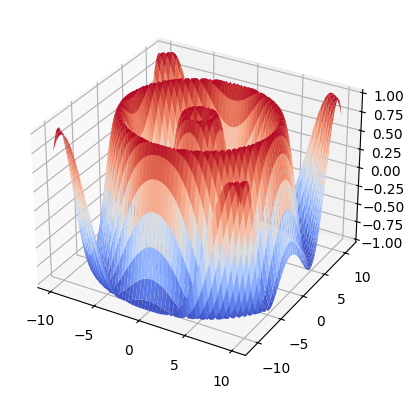

In [12]:
import matplotlib.pyplot as plt
from matplotlib import cm

zoom = 10
numbers = 100
x = np.linspace(-zoom, zoom, numbers)
y = np.linspace(-zoom-1, zoom+1, numbers)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y **2))

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm)
plt.show()

### 模仿实现 + 遇到问题

【问题1】

在 Python 中，`else` 与 `for` 循环对齐是一种特殊的语法，被称为 `for-else` 结构。
它的逻辑是：如果循环是"正常结束"的（即没有被 `break` 语句中断），则执行 `else` 块中的代码。
在这个分形计算（通常是曼德博集合）的例子中，这样写非常高效：

1.  `if abs(z) > 200: break`：
    一旦点逃逸（发散），立刻跳出循环，此时 `else` 里的代码不会执行。
2.  `else: M[i, j] = max_iter`：
    只有当循环跑满了 `max_iter` 次，且从未触发过 `break`（意味着该点在多次迭代后依然保持稳定，属于集合内部），才会执行这个赋值。

这种写法的优点：

-   简洁：不需要额外定义一个布尔变量（如 `is_diverged = False`）来标记循环是否提前结束。
-   逻辑清晰：直接区分了"中途逃逸"和"跑满全程"两种情况。

语义对比：

-   有 `break` $\\rightarrow$ 逻辑上是"找到了"或"出局了"，跳过 `else`。
-   无 `break`（自然结束） $\\rightarrow$ 逻辑上是"没找到"或"坚持到了最后"，执行 `else`。

【这是python的语法糖？】

这确实是 Python 的一种**原生语法特性**（虽然不算严格意义上的"简写"糖，但确实让逻辑更精简）。在 Python 官方文档中，它被称为 **`for...else` 语句**。
简单来说，它的设计逻辑是：**"如果没有 break，就执行 else"。**


【问题2】

```
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16636\594698748.py:18: RuntimeWarning: overflow encountered in scalar power
  z = z ** 2 + c
```
在复数运算中，不能直接用 `z > 200`，因为复数（二维）无法直接与实数进行大小比较。

`abs()` 能算复数是因为它是 Python 的 **内置函数**，并且它能根据传入对象的类型自动调用对应的底层方法。

在 Python 中，对一个复数（`complex`）使用 `abs(z)`，它等同于计算该复数的 **模（Magnitude）**。


In [25]:
import numpy as np
import matplotlib.pyplot as plt

def julia_set(c, width, height, zoom, max_iter):
    # 创建复平面上的网格
    x = np.linspace(-zoom, zoom, width)
    y = np.linspace(-zoom, zoom, height)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    
    # 初始化迭代次数矩阵
    M = np.zeros((width, height))

    for i in range(width):
        for j in range(height):
            z = Z[i, j]
            for s in range(max_iter):
                z = z ** 2 + c # Note: 迭代
                if abs(z) > 200:
                    M[i, j] = s
                    break
            else:
                M[i, j] = max_iter
    return M

# 参数设置
c = complex(-0.8, 0.29)  # 复数常数，改变此值可得到不同形状的 Julia 集
width, height = 400, 400    # 图像分辨率
zoom = 1.5                  # 视图缩放
max_iter = 200              # 最大迭代次数

# 生成数据
J = julia_set(c, width, height, zoom, max_iter)



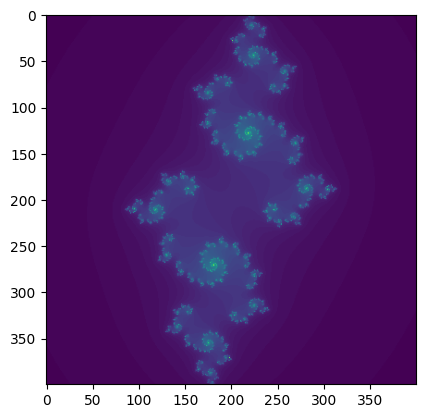

In [26]:
plt.imshow(J.T)
plt.show()

### 性能改进


1\. 内存视图与赋值协议
在 Python 中，`a[b]` 如果出现在**赋值符号（`=`）左侧**，它触发的是对象的 `__setitem__` 方法。NumPy 会根据布尔掩码 `b` 找到 `a` 中对应的内存地址，直接将新值写入这些特定的内存位置。

2\. 原地修改（In-place）

-   **如果不加等号**：`a[b]` 会创建一个新的临时数组（副本），所以你只看到提取出的值。
-   **如果加上等号**：`a[b] = ...` 则是一个**赋值操作**。它告诉 NumPy："去 `a` 里面，把所有 `b` 为 `True` 的坐标找出来，把右边的值填进去。"

In [32]:

a = np.arange(4).reshape((2, 2))
 
# a[b] 会提取出所有对应位置为 True 的元素。
# 注意： 无论原数组是几维，筛选后的结果都会被“展平”为一个一维数组。
b = a > 2
print(a[b])
a[b] = a[b] ** 2
a

[3]


array([[0, 1],
       [2, 9]])

In [33]:
a = np.array([1, 2, 3, 4])
b = [True, True, False, False]  # 选前两个位置
c = [False, False, True, True]  # 选后两个位置

a[b] = a[c] ** 2
a

array([ 9, 16,  3,  4])

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def julia_set(c, width, height, zoom, max_iter):
    # 创建复平面上的网格
    x = np.linspace(-zoom, zoom, width)
    y = np.linspace(-zoom, zoom, height)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    
    # 初始化迭代次数矩阵
    M = np.full(Z.shape, max_iter, dtype=int)

    escape_mask = np.full((width, height), True, dtype=bool)

    for k in range(max_iter):
        Z[escape_mask] = Z[escape_mask] ** 2 + c

        escaping = (np.abs(Z) > 200) & escape_mask

        M[escape_mask] = k
        escape_mask[np.abs(Z) > 200] = False

        if not np.any(escape_mask): break

    return M


# 参数设置
c = complex(-0.8, 0.29)  # 复数常数，改变此值可得到不同形状的 Julia 集
width, height = 400, 400    # 图像分辨率
zoom = 1.5                  # 视图缩放
max_iter = 200              # 最大迭代次数

# 生成数据
J = julia_set(c, width, height, zoom, max_iter)

# plt.imshow(J.T)
# plt.show()

### 原版实现

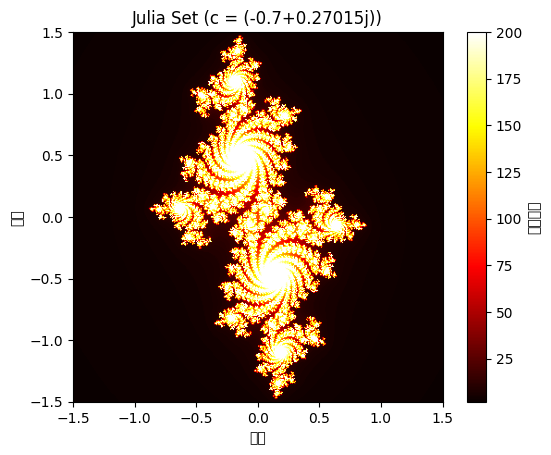

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def julia_set(c, width, height, zoom, max_iter):
    # 创建复平面上的网格
    x = np.linspace(-zoom, zoom, width)
    y = np.linspace(-zoom, zoom, height)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    
    # 初始化迭代次数矩阵
    M = np.zeros((width, height))
    
    # 对每个点进行迭代
    for i in range(width):
        for j in range(height):
            z = Z[i, j]
            for k in range(max_iter):
                # 核心迭代方程：z = z^2 + c
                z = z**2 + c
                # 如果发散（趋向无穷大，通常模大于 2 即视为发散）
                if abs(z) > 200:
                    M[i, j] = k
                    break
            else:
                # 如果保持有界（达到最大迭代次数仍未发散）
                M[i, j] = max_iter
                
    return M

# 参数设置
c = complex(-0.7, 0.27015)  # 复数常数，改变此值可得到不同形状的 Julia 集
width, height = 400, 400    # 图像分辨率
zoom = 1.5                  # 视图缩放
max_iter = 200              # 最大迭代次数

# 生成数据
J = julia_set(c, width, height, zoom, max_iter)

# 绘制图像
plt.imshow(J.T, extent=[-zoom, zoom, -zoom, zoom], cmap='hot', origin='lower')
plt.colorbar(label='迭代次数')
plt.title(f'Julia Set (c = {c})')
plt.xlabel('实部')
plt.ylabel('虚部')
plt.show()